# GHCN SNWD Baseline Core (OL vs DA)

This streamlined notebook keeps only the **baseline** workflow:

1. Load the existing raw daily cache (`obs_snwd_mm`, `model_snwd_mm`) for OL/DA.
2. Apply the same baseline station pre-filter logic used in the full notebook.
3. Compute station metrics: `R`, `anomR`, `rmse`, `ubrmse`, `bias`, `abs_bias`.
4. Make OL-vs-DA seasonal bar plots and NH Robinson maps of `DA - OL` metric deltas.

Notes:
- `anomR` here is anomaly correlation after removing each series' **month-of-year climatology** on paired valid samples.
- Map season defaults to `ALL` (same baseline ALL mask logic as full notebook).


In [1]:
# --- Imports + configuration ---
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

from pathlib import Path
from typing import Optional
import json
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)

# Resolve PROJ data dir dynamically from pyproj and override bad inherited paths.
PROJ_DIR = None
try:
    from pyproj import datadir as _pyproj_datadir
    _p = Path(_pyproj_datadir.get_data_dir())
    if _p.exists():
        PROJ_DIR = _p
        os.environ['PROJ_LIB'] = str(_p)
        os.environ['PROJ_DATA'] = str(_p)
except Exception:
    PROJ_DIR = None
print(f'PROJ_DIR={PROJ_DIR}')

import cartopy

# Prefer existing local Cartopy Natural Earth cache to avoid network downloads.
CARTOPY_DATA_DIR_CANDIDATES = [
    Path('/home/amfox/.local/share/cartopy'),
    Path.home() / '.local' / 'share' / 'cartopy',
]
CARTOPY_DATA_DIR = next((d for d in CARTOPY_DATA_DIR_CANDIDATES if d.exists()), CARTOPY_DATA_DIR_CANDIDATES[0])
cartopy.config['data_dir'] = str(CARTOPY_DATA_DIR)
print(f'CARTOPY_DATA_DIR={CARTOPY_DATA_DIR}')

SEASON_ORDER = ['DJF', 'MAM', 'JJA', 'SON']
SEASONS_PLOT = ['ALL', 'DJF', 'MAM', 'SON']  # keep JJA out of bars
MAP_SEASON = 'ALL'

EXCLUDE_JJA_FROM_ALL = True
EXCLUDE_DJF_FROM_ALL_FOR_SH = True

# Build-time station/data thresholds (same baseline approach as full notebook)
MIN_VALID_DAYS = 1500
MIN_AVG_SNOW_DAYS_PER_YEAR = 5.0
MAX_DISTANCE_KM = 40.0
MAX_ABS_ELEV_DIFF_M = 500.0
DISTANCE_METHOD = 'haversine_km'
MAX_DISTANCE_DEG2 = 0.10

QC_MIN_MM = 0.0
QC_MAX_MM = 5000.0

PRE_STATS_MIN_COMMON_PAIRED_DAYS = 1500
PRE_STATS_MIN_COMMON_OBS_SNOW_DAYS_PER_YEAR = 5.0

MODEL_SCF_VAR_CANDIDATES = ('FRLANDSNO', 'FRSNO', 'SNCOVFR', 'SNOWCOVERFR', 'SCF')

EXP_OL = 'OL'
EXP_DA = 'DA'

# Notebook-local path overrides (edit these directly for other systems).
GEOSLDAS_ANALYSIS_ROOT = None  # auto-detect from cwd; fallback to Discover path below
GEOSLDAS_IO_DIR = None  # optional explicit override, e.g., Path('/path/to/common/python/io')
GHCN_SNWD_BUILD_OUTDIR_OVERRIDE = None  # auto from repo root; fallback to Discover path below
GHCN_SNWD_OUTPUT_DIR = None  # default: <repo>/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation
GHCN_SNWD_OL_RUN_ROOT = Path('/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36')
GHCN_SNWD_DA_RUN_ROOT = Path('/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3/LS_DAv8_M36')

DISCOVER_REPO_ROOT = Path('/discover/nobackup/projects/land_da/geosldas-analysis')
DISCOVER_GHCN_BUILD_OUTDIR = DISCOVER_REPO_ROOT / 'ghcn_snwd_build' / 'output'

EXPERIMENTS = {
    'OL': {
        'exp_name': 'LS_OLv8_M36',
        'run_root': Path(GHCN_SNWD_OL_RUN_ROOT),
    },
    'DA': {
        'exp_name': 'LS_DAv8_M36',
        'run_root': Path(GHCN_SNWD_DA_RUN_ROOT),
    },
}

ANALYSIS_START = '2000-01-01'
ANALYSIS_END = '2024-12-31'
DOMAIN = 'SMAP_EASEv2_M36_GLOBAL'

USE_RAW_TIMESERIES_CACHE = True
WRITE_RAW_TIMESERIES_CACHE = True

REBUILD_BASELINE_METRICS = False
BOOT_N = 1000
BOOT_CI = 95.0
BOOT_SEED = 42
STATION_CHUNK = 512


def _find_repo_root_from_cwd() -> Optional[Path]:
    c0 = Path.cwd().resolve()
    candidates = [c0, *c0.parents]
    for cand in candidates:
        if (cand / 'common/python/io/read_GEOSldas.py').exists():
            return cand
    return None


# Resolve REPO_ROOT (prefer explicit override, then cwd auto-detect, then Discover fallback).
if GEOSLDAS_ANALYSIS_ROOT is not None:
    REPO_ROOT = Path(GEOSLDAS_ANALYSIS_ROOT).expanduser().resolve()
else:
    _rr = _find_repo_root_from_cwd()
    if _rr is not None:
        REPO_ROOT = _rr
    elif DISCOVER_REPO_ROOT.exists() and (DISCOVER_REPO_ROOT / 'common/python/io/read_GEOSldas.py').exists():
        REPO_ROOT = DISCOVER_REPO_ROOT
    else:
        REPO_ROOT = None

# Resolve read_GEOSldas import directory.
if GEOSLDAS_IO_DIR is not None:
    geosldas_io_dir = Path(GEOSLDAS_IO_DIR).expanduser().resolve()
elif REPO_ROOT is not None:
    geosldas_io_dir = REPO_ROOT / 'common' / 'python' / 'io'
else:
    geosldas_io_dir = None

if geosldas_io_dir is None or not (geosldas_io_dir / 'read_GEOSldas.py').exists():
    raise FileNotFoundError(
        'Could not locate read_GEOSldas.py. Set GEOSLDAS_IO_DIR to common/python/io '
        'or set GEOSLDAS_ANALYSIS_ROOT to the repo root.'
    )

sys.path.insert(0, str(geosldas_io_dir))
from read_GEOSldas import read_tilecoord  # type: ignore

# Resolve project/output locations.
if REPO_ROOT is not None and (REPO_ROOT / 'projects' / 'GHCN_snwd').exists():
    PROJECT_ROOT = (REPO_ROOT / 'projects' / 'GHCN_snwd').resolve()
else:
    PROJECT_ROOT = Path.cwd().resolve()

if GHCN_SNWD_OUTPUT_DIR is not None:
    OUTPUT_DIR = Path(GHCN_SNWD_OUTPUT_DIR).expanduser().resolve()
elif REPO_ROOT is not None and (REPO_ROOT / 'projects' / 'GHCN_snwd').exists():
    OUTPUT_DIR = (REPO_ROOT / 'projects' / 'GHCN_snwd' / 'outputs_ghcn_snwd_ol_da_validation').resolve()
else:
    OUTPUT_DIR = (PROJECT_ROOT / 'outputs_ghcn_snwd_ol_da_validation').resolve()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Resolve GHCN build output root.
if GHCN_SNWD_BUILD_OUTDIR_OVERRIDE is not None:
    GHCN_BUILD_OUTDIR = Path(GHCN_SNWD_BUILD_OUTDIR_OVERRIDE).expanduser().resolve()
elif REPO_ROOT is not None:
    GHCN_BUILD_OUTDIR = (REPO_ROOT / 'ghcn_snwd_build' / 'output').resolve()
elif DISCOVER_GHCN_BUILD_OUTDIR.exists():
    GHCN_BUILD_OUTDIR = DISCOVER_GHCN_BUILD_OUTDIR.resolve()
else:
    GHCN_BUILD_OUTDIR = (PROJECT_ROOT / 'ghcn_snwd_build' / 'output').resolve()

GHCN_MANIFEST = GHCN_BUILD_OUTDIR / 'ghcn_snwd_manifest.json'
GHCN_STATION_META = GHCN_BUILD_OUTDIR / 'ghcn_snwd_station_metadata.parquet'
GHCN_STATION_COVERAGE = GHCN_BUILD_OUTDIR / 'ghcn_snwd_station_coverage.parquet'
GHCN_PARQUET_DIR = GHCN_BUILD_OUTDIR / 'ghcn_snwd_parquet'

cache_tag = f"{DOMAIN}_{pd.Timestamp(ANALYSIS_START):%Y%m%d}_{pd.Timestamp(ANALYSIS_END):%Y%m%d}"

RAW_TIMESERIES_NC = OUTPUT_DIR / f'ghcn_snwd_raw_timeseries_{cache_tag}.nc'

STATION_MAP_CSV = {
    k: OUTPUT_DIR / f'ghcn_station_tile_map_{k}_{cache_tag}.csv'
    for k in EXPERIMENTS.keys()
}
SELECTION_SUMMARY_PARQUET = OUTPUT_DIR / f'ghcn_station_selection_summary_{cache_tag}.parquet'
SELECTION_SUMMARY_CSV = OUTPUT_DIR / f'ghcn_station_selection_summary_{cache_tag}.csv'
ANNUAL_COUNTS_PARQUET = OUTPUT_DIR / f'ghcn_station_year_counts_{cache_tag}.parquet'

STATION_METRICS_CSV = OUTPUT_DIR / f'ghcn_station_metrics_baseline_core_{cache_tag}.csv'
DOMAIN_METRICS_CSV = OUTPUT_DIR / f'ghcn_domain_metrics_baseline_core_{cache_tag}.csv'

print(f'REPO_ROOT={REPO_ROOT}')
print(f'GEOSLDAS_IO_DIR={geosldas_io_dir}')
print(f'PROJECT_ROOT={PROJECT_ROOT}')
print(f'GHCN_BUILD_OUTDIR={GHCN_BUILD_OUTDIR}')
print(f'RAW_TIMESERIES_NC={RAW_TIMESERIES_NC}')
print(f'STATION_METRICS_CSV={STATION_METRICS_CSV}')
print(f'DOMAIN_METRICS_CSV={DOMAIN_METRICS_CSV}')
print(f'REBUILD_BASELINE_METRICS={REBUILD_BASELINE_METRICS}')
for k, cfg in EXPERIMENTS.items():
    print(f"{k}: exp_name={cfg['exp_name']}, run_root={cfg['run_root']}")


REPO_ROOT=/Users/amfox/Desktop/geosldas-analysis
GEOSLDAS_IO_DIR=/Users/amfox/Desktop/geosldas-analysis/common/python/io
PROJECT_ROOT=/Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd
GHCN_BUILD_OUTDIR=/Users/amfox/Desktop/geosldas-analysis/ghcn_snwd_build/output
RAW_TIMESERIES_NC=/Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_snwd_raw_timeseries_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.nc
STATION_METRICS_CSV=/Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_station_metrics_baseline_core_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.csv
DOMAIN_METRICS_CSV=/Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_domain_metrics_baseline_core_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.csv
REBUILD_BASELINE_METRICS=False
OL: exp_name=LS_OLv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36
DA: exp_name=LS_D

In [2]:
# --- Helper functions ---
def haversine_km(lat1, lon1, lat2, lon2):
    # Vectorized Haversine distance in kilometers; lat2/lon2 can be arrays.
    r = 6371.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dlambda = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


def locate_tilecoord_file(run_root: Path, exp_name: str, domain: str, output_dir: Path) -> Path:
    candidates = [
        output_dir / 'tilecoord.bin',
        output_dir / f'{exp_name}.ldas_tilecoord.bin',
        run_root / 'output' / domain / 'rc_out' / f'{exp_name}.ldas_tilecoord.bin',
        run_root / exp_name / 'output' / domain / 'rc_out' / f'{exp_name}.ldas_tilecoord.bin',
        run_root / f'{exp_name}.ldas_tilecoord.bin',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Could not find tilecoord file. Checked: ' + ', '.join([str(p) for p in candidates]))


def locate_daily_cat_file(run_root: Path, exp_name: str, domain: str, day: pd.Timestamp):
    y = f'Y{day.year:04d}'
    m = f'M{day.month:02d}'
    stamp = day.strftime('%Y%m%d')
    fname = f'{exp_name}.tavg24_1d_lnd_Nt.{stamp}_1200z.nc4'
    candidates = [
        run_root / 'output' / domain / 'cat' / 'ens_avg' / y / m / fname,
        run_root / exp_name / 'output' / domain / 'cat' / 'ens_avg' / y / m / fname,
        run_root / 'cat' / 'ens_avg' / y / m / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def _read_var_1d_tile(ds, name):
    x = ds[name]
    if 'time' in x.dims:
        x = x.isel(time=0)
    return np.asarray(x.values, dtype=np.float32)


def read_daily_snwd_for_tiles(nc_path: Path, tile_indices: np.ndarray, scf_var_candidates=MODEL_SCF_VAR_CANDIDATES):
    # Read SNODPLAND (m) and snow-cover fraction, then return grid-cell-average depth in mm.
    with xr.open_dataset(nc_path, decode_times=False) as ds:
        snod = _read_var_1d_tile(ds, 'SNODPLAND')

        scf_name = next((v for v in scf_var_candidates if v in ds.variables), None)
        if scf_name is None:
            raise KeyError(
                f'No snow-cover fraction variable found in {nc_path}. Tried: {list(scf_var_candidates)}'
            )
        scf = _read_var_1d_tile(ds, scf_name)

    snod_sel_m = np.asarray(snod[tile_indices], dtype=np.float32)
    scf_sel = np.asarray(scf[tile_indices], dtype=np.float32)

    snod_sel_m[snod_sel_m > 1e14] = np.nan
    snod_sel_m[snod_sel_m < 0.0] = np.nan
    scf_sel[scf_sel > 1e14] = np.nan

    # Handle either [0..1] fraction or [0..100] percent.
    scf_max = np.nanmax(scf_sel) if np.any(np.isfinite(scf_sel)) else np.nan
    if np.isfinite(scf_max) and (scf_max > 1.5) and (scf_max <= 100.0):
        scf_sel = scf_sel / 100.0

    scf_sel = np.clip(scf_sel, 0.0, 1.0)
    return (snod_sel_m * scf_sel) * 1000.0


def map_stations_to_tiles(
    tile_lat,
    tile_lon,
    tile_elev,
    station_df,
    distance_method='haversine_km',
    max_distance_deg2=0.1,
    max_distance_km=40.0,
):
    rows = []
    tile_lat = np.asarray(tile_lat, dtype=float)
    tile_lon = np.asarray(tile_lon, dtype=float)
    tile_elev = np.asarray(tile_elev, dtype=float)

    for _, r in station_df.iterrows():
        stn = str(r['station'])
        lat = float(r['station_lat'])
        lon = float(r['station_lon'])
        station_elev_m = float(r['station_elev_m']) if np.isfinite(r['station_elev_m']) else np.nan

        if not (np.isfinite(lat) and np.isfinite(lon)):
            continue

        if distance_method == 'squared_degree':
            d_metric = (tile_lat - lat) ** 2 + (tile_lon - lon) ** 2
            j = int(np.argmin(d_metric))
            metric_val = float(d_metric[j])
            if max_distance_deg2 is not None and metric_val > float(max_distance_deg2):
                continue
            d_km = float(haversine_km(lat, lon, np.array([tile_lat[j]]), np.array([tile_lon[j]]))[0])
        elif distance_method == 'haversine_km':
            d = haversine_km(lat, lon, tile_lat, tile_lon)
            j = int(np.argmin(d))
            d_km = float(d[j])
            if max_distance_km is not None and d_km > float(max_distance_km):
                continue
            metric_val = d_km
        else:
            raise ValueError(f'Unsupported distance_method={distance_method}')

        this_tile_elev = float(tile_elev[j]) if np.isfinite(tile_elev[j]) else np.nan
        elev_diff_m = np.nan
        if np.isfinite(this_tile_elev) and np.isfinite(station_elev_m):
            elev_diff_m = this_tile_elev - station_elev_m

        rows.append(
            {
                'station': stn,
                'station_lat': lat,
                'station_lon': lon,
                'station_elev_m': station_elev_m,
                'tile_index': j,
                'tile_lat': float(tile_lat[j]),
                'tile_lon': float(tile_lon[j]),
                'tile_elev_m': this_tile_elev,
                'elev_diff_m': elev_diff_m,
                'distance_km': d_km,
                'distance_metric': metric_val,
                'distance_method': distance_method,
            }
        )

    out_cols = [
        'station', 'station_lat', 'station_lon', 'station_elev_m',
        'tile_index', 'tile_lat', 'tile_lon', 'tile_elev_m', 'elev_diff_m',
        'distance_km', 'distance_metric', 'distance_method',
    ]
    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)
    return pd.DataFrame(rows)[out_cols].sort_values('distance_km').reset_index(drop=True)


def build_obs_matrix(obs_df: pd.DataFrame, model_days: pd.DatetimeIndex, stations, value_col: str) -> np.ndarray:
    piv = obs_df.pivot_table(index='date', columns='station', values=value_col, aggfunc='mean')
    piv = piv.reindex(index=model_days, columns=stations)
    return np.asarray(piv.to_numpy(dtype=np.float32), dtype=np.float32)


def season_name(ts: pd.Timestamp) -> str:
    m = int(ts.month)
    if m in (12, 1, 2):
        return 'DJF'
    if m in (3, 4, 5):
        return 'MAM'
    if m in (6, 7, 8):
        return 'JJA'
    return 'SON'


def _corr_cols(a: np.ndarray, b: np.ndarray):
    valid = np.isfinite(a) & np.isfinite(b)
    n = np.sum(valid, axis=0).astype(np.int32)

    a2 = np.where(valid, a, np.nan)
    b2 = np.where(valid, b, np.nan)

    am = np.nanmean(a2, axis=0)
    bm = np.nanmean(b2, axis=0)

    ac = a2 - am
    bc = b2 - bm

    cov = np.nanmean(ac * bc, axis=0)
    sa = np.nanstd(a2, axis=0)
    sb = np.nanstd(b2, axis=0)

    r = cov / (sa * sb)
    r[(n < 2) | ~np.isfinite(sa) | ~np.isfinite(sb) | (sa == 0) | (sb == 0)] = np.nan
    return r, n


def _anom_corr_monthly_clim(time_idx: pd.DatetimeIndex, obs: np.ndarray, mod: np.ndarray) -> np.ndarray:
    months = time_idx.month.to_numpy(dtype=np.int8)

    oa = obs.copy()
    ma = mod.copy()

    for mm in range(1, 13):
        idx = months == mm
        if not np.any(idx):
            continue

        o_sub = oa[idx, :]
        m_sub = ma[idx, :]

        o_clim = np.nanmean(o_sub, axis=0)
        m_clim = np.nanmean(m_sub, axis=0)

        oa[idx, :] = o_sub - o_clim
        ma[idx, :] = m_sub - m_clim

    r_anom, _ = _corr_cols(oa, ma)
    return r_anom


def _bootstrap_mean_ci(vals: np.ndarray, n_boot: int = BOOT_N, ci: float = BOOT_CI, seed: int = BOOT_SEED):
    x = np.asarray(vals, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mu = float(np.mean(x))
    if n == 1:
        return mu, mu, mu, 1

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    means = x[idx].mean(axis=1)

    alpha = (100.0 - ci) / 2.0
    lo = float(np.nanpercentile(means, alpha))
    hi = float(np.nanpercentile(means, 100.0 - alpha))
    return mu, lo, hi, int(n)


In [3]:
# --- Load raw cache or build from source files ---
loaded_from_cache = False
raw_ds = None
model_days = pd.date_range(pd.Timestamp(ANALYSIS_START), pd.Timestamp(ANALYSIS_END), freq='D')


def _cache_validation_errors(ds: xr.Dataset):
    errs = []
    required_vars = [
        'obs_snwd_mm',
        'model_snwd_mm',
        'station_lat',
        'station_lon',
        'tile_index',
        'tile_elev_m',
        'distance_km',
        'elev_diff_m',
    ]
    for v in required_vars:
        if v not in ds.data_vars:
            errs.append(f'missing variable: {v}')

    expected_exp = [str(k) for k in EXPERIMENTS.keys()]
    got_exp = [str(x) for x in ds.coords['exp'].values] if 'exp' in ds.coords else []
    if got_exp != expected_exp:
        errs.append(f'exp coord mismatch: cache={got_exp} vs config={expected_exp}')

    if 'time' not in ds.coords:
        errs.append('missing coord: time')
    else:
        got_time = pd.to_datetime(ds['time'].values)
        if len(got_time) != len(model_days):
            errs.append(f'time length mismatch: cache={len(got_time)} vs expected={len(model_days)}')

    if 'station' not in ds.coords:
        errs.append('missing coord: station')
    elif int(ds.sizes.get('station', 0)) == 0:
        errs.append('station dimension is empty')

    if str(ds.attrs.get('domain', '')) != str(DOMAIN):
        errs.append(f"domain mismatch: cache={ds.attrs.get('domain')} vs config={DOMAIN}")

    return errs


if USE_RAW_TIMESERIES_CACHE and RAW_TIMESERIES_NC.exists():
    print(f'Found raw cache: {RAW_TIMESERIES_NC}')
    tmp_ds = xr.open_dataset(RAW_TIMESERIES_NC)
    cache_errs = _cache_validation_errors(tmp_ds)

    if len(cache_errs) == 0:
        raw_ds = tmp_ds
        loaded_from_cache = True
        print('Using existing raw cache (configuration match).')
    else:
        print('Existing raw cache does not match current configuration; re-extracting.')
        for msg in cache_errs:
            print(f'  - {msg}')
        try:
            tmp_ds.close()
        except Exception:
            pass
elif USE_RAW_TIMESERIES_CACHE:
    print(f'Raw cache not found: {RAW_TIMESERIES_NC}')
    print('Running extraction from daily cat files...')
else:
    print('USE_RAW_TIMESERIES_CACHE=False; running extraction from daily cat files...')


if not loaded_from_cache:
    # 1) Load GHCN build products.
    if not GHCN_MANIFEST.exists():
        raise FileNotFoundError(f'Manifest not found: {GHCN_MANIFEST}')
    if not GHCN_STATION_META.exists():
        raise FileNotFoundError(f'Station metadata not found: {GHCN_STATION_META}')
    if not GHCN_STATION_COVERAGE.exists():
        raise FileNotFoundError(f'Station coverage not found: {GHCN_STATION_COVERAGE}')
    if not GHCN_PARQUET_DIR.exists():
        raise FileNotFoundError(f'Observation parquet directory not found: {GHCN_PARQUET_DIR}')

    with open(GHCN_MANIFEST, 'r') as f:
        _manifest = json.load(f)

    station_meta = pd.read_parquet(GHCN_STATION_META).copy()
    station_coverage = pd.read_parquet(GHCN_STATION_COVERAGE).copy()

    station_meta['station_id'] = station_meta['station_id'].astype(str)
    station_coverage['station_id'] = station_coverage['station_id'].astype(str)

    station_meta['lat'] = pd.to_numeric(station_meta['lat'], errors='coerce')
    station_meta['lon'] = pd.to_numeric(station_meta['lon'], errors='coerce')
    station_meta['elev'] = pd.to_numeric(station_meta['elev'], errors='coerce')

    print('Manifest keys:', sorted(_manifest.keys()))
    print(f'Station metadata rows: {len(station_meta):,}')
    print(f'Station coverage rows: {len(station_coverage):,}')

    # 2) Build station-year counts and apply observation filters.
    analysis_start_ts = pd.Timestamp(ANALYSIS_START)
    analysis_end_ts = pd.Timestamp(ANALYSIS_END)
    analysis_years = list(range(analysis_start_ts.year, analysis_end_ts.year + 1))

    annual_parts = []
    for year in analysis_years:
        part_dir = GHCN_PARQUET_DIR / f'year={year}'
        if not part_dir.exists():
            print(f'Missing partition for year={year}; treating as zero observations for all stations.')
            continue

        df = pd.read_parquet(part_dir, columns=['station_id', 'date', 'snwd_mm']).copy()
        if df.empty:
            continue

        df['station_id'] = df['station_id'].astype(str)
        df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
        df['snwd_mm'] = pd.to_numeric(df['snwd_mm'], errors='coerce')
        df = df[(df['date'] >= analysis_start_ts) & (df['date'] <= analysis_end_ts)].copy()
        if df.empty:
            continue

        grouped = (
            df.assign(snow_day=(df['snwd_mm'] > 0).astype(np.int16))
            .groupby('station_id', as_index=False)
            .agg(
                valid_days=('snwd_mm', 'count'),
                snow_days=('snow_day', 'sum'),
            )
            .rename(columns={'station_id': 'station'})
        )
        grouped['year'] = int(year)
        annual_parts.append(grouped)

    if len(annual_parts) == 0:
        raise RuntimeError('No observation rows found in configured analysis period')

    annual_df = pd.concat(annual_parts, ignore_index=True)

    all_stations = station_meta['station_id'].dropna().astype(str).unique().tolist()
    full_index = pd.MultiIndex.from_product([all_stations, analysis_years], names=['station', 'year'])
    annual_full = (
        annual_df.set_index(['station', 'year'])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    annual_full['valid_days'] = pd.to_numeric(annual_full['valid_days'], errors='coerce').fillna(0).astype(int)
    annual_full['snow_days'] = pd.to_numeric(annual_full['snow_days'], errors='coerce').fillna(0).astype(int)
    annual_full['has_obs'] = annual_full['valid_days'] > 0

    annual_full.to_parquet(ANNUAL_COUNTS_PARQUET, index=False)

    station_summary = (
        annual_full.groupby('station', as_index=False)
        .agg(
            n_valid_days=('valid_days', 'sum'),
            avg_snow_days_per_year=('snow_days', 'mean'),
            n_years_with_obs=('has_obs', 'sum'),
        )
    )

    station_summary = station_summary.merge(
        station_meta[['station_id', 'lat', 'lon', 'elev', 'name', 'state', 'gsn_flag', 'hcn_crn_flag', 'wmo_id']],
        left_on='station',
        right_on='station_id',
        how='left',
    )

    station_summary = station_summary.rename(
        columns={
            'lat': 'station_lat',
            'lon': 'station_lon',
            'elev': 'station_elev_m',
            'name': 'station_name',
            'state': 'station_state',
        }
    )

    coord_ok = (
        np.isfinite(pd.to_numeric(station_summary['station_lat'], errors='coerce'))
        & np.isfinite(pd.to_numeric(station_summary['station_lon'], errors='coerce'))
    )
    station_summary = station_summary.loc[coord_ok].copy()

    obs_filtered_stations = station_summary.loc[
        (station_summary['n_valid_days'] >= int(MIN_VALID_DAYS))
        & (station_summary['avg_snow_days_per_year'] >= float(MIN_AVG_SNOW_DAYS_PER_YEAR))
    ].copy()

    print(f'Stations with valid coordinates: {len(station_summary):,}')
    print(f'Stations after obs filters: {len(obs_filtered_stations):,}')

    if len(obs_filtered_stations) == 0:
        raise RuntimeError('No stations pass observation filters. Relax thresholds or inspect counts.')

    # 3) Map stations to GEOSldas tiles and apply mapping constraints.
    site_maps = {}
    for exp_key, cfg in EXPERIMENTS.items():
        exp_name = cfg['exp_name']
        run_root = Path(cfg['run_root'])

        tilecoord_path = locate_tilecoord_file(run_root, exp_name, DOMAIN, OUTPUT_DIR)
        tc = read_tilecoord(str(tilecoord_path))

        tile_lat_arr = np.asarray(tc['com_lat'], dtype=float)
        tile_lon_arr = np.asarray(tc['com_lon'], dtype=float)
        tile_elev_arr = np.asarray(tc['elev'], dtype=float) if 'elev' in tc else np.full(tile_lat_arr.shape, np.nan)

        map_df = map_stations_to_tiles(
            tile_lat_arr,
            tile_lon_arr,
            tile_elev_arr,
            obs_filtered_stations[['station', 'station_lat', 'station_lon', 'station_elev_m']],
            distance_method=DISTANCE_METHOD,
            max_distance_deg2=MAX_DISTANCE_DEG2,
            max_distance_km=MAX_DISTANCE_KM,
        )

        map_df['abs_elev_diff_m'] = np.abs(pd.to_numeric(map_df['elev_diff_m'], errors='coerce'))
        map_df = map_df.loc[
            (pd.to_numeric(map_df['distance_km'], errors='coerce') <= float(MAX_DISTANCE_KM))
            & (map_df['abs_elev_diff_m'] <= float(MAX_ABS_ELEV_DIFF_M))
        ].copy()

        if len(map_df) == 0:
            raise RuntimeError(f'No stations remain after mapping constraints for {exp_key}')

        site_maps[exp_key] = map_df
        map_df.to_csv(STATION_MAP_CSV[exp_key], index=False)
        print(f"{exp_key}: mapped + constrained stations={len(map_df):,} -> {STATION_MAP_CSV[exp_key]}")

    common_stations = sorted(set.intersection(*[set(df['station']) for df in site_maps.values()]))
    if len(common_stations) == 0:
        raise RuntimeError('No common stations across OL and DA after mapping constraints')

    selected_station_df = (
        obs_filtered_stations[obs_filtered_stations['station'].isin(common_stations)]
        .sort_values(['n_valid_days', 'avg_snow_days_per_year'], ascending=[False, False])
        .reset_index(drop=True)
    )

    selected_station_df.to_parquet(SELECTION_SUMMARY_PARQUET, index=False)
    selected_station_df.to_csv(SELECTION_SUMMARY_CSV, index=False)

    print(f'Final selected stations (common OL/DA): {len(selected_station_df):,}')

    # 4) Build raw timeseries matrices.
    station_list = selected_station_df['station'].astype(str).tolist()
    station_set = set(station_list)

    obs_parts = []
    for year in range(pd.Timestamp(ANALYSIS_START).year, pd.Timestamp(ANALYSIS_END).year + 1):
        part_dir = GHCN_PARQUET_DIR / f'year={year}'
        if not part_dir.exists():
            continue

        df = pd.read_parquet(part_dir, columns=['station_id', 'date', 'snwd_mm']).copy()
        if df.empty:
            continue

        df['station_id'] = df['station_id'].astype(str)
        df = df[df['station_id'].isin(station_set)].copy()
        if df.empty:
            continue

        df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
        df['snwd_mm'] = pd.to_numeric(df['snwd_mm'], errors='coerce')
        df = df[(df['date'] >= pd.Timestamp(ANALYSIS_START)) & (df['date'] <= pd.Timestamp(ANALYSIS_END))].copy()
        if df.empty:
            continue

        obs_parts.append(df.rename(columns={'station_id': 'station'})[['station', 'date', 'snwd_mm']])

    if len(obs_parts) == 0:
        raise RuntimeError('No observation rows found for selected stations')

    obs_daily = (
        pd.concat(obs_parts, ignore_index=True)
        .groupby(['station', 'date'], as_index=False)
        .agg(snwd_mm=('snwd_mm', 'mean'))
    )

    obs_snwd_mm = build_obs_matrix(obs_daily, model_days, station_list, 'snwd_mm')

    exp_keys = list(EXPERIMENTS.keys())
    n_exp = len(exp_keys)
    n_time = len(model_days)
    n_station = len(station_list)

    model_snwd_mm = np.full((n_exp, n_time, n_station), np.nan, dtype=np.float32)
    tile_index = np.full((n_exp, n_station), -1, dtype=np.int32)
    tile_lat = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    tile_lon = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    tile_elev_m = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    distance_km = np.full((n_exp, n_station), np.nan, dtype=np.float32)
    elev_diff_m = np.full((n_exp, n_station), np.nan, dtype=np.float32)

    for ei, exp_key in enumerate(exp_keys):
        cfg = EXPERIMENTS[exp_key]
        exp_name = cfg['exp_name']
        run_root = Path(cfg['run_root'])

        m = site_maps[exp_key].set_index('station').loc[station_list].reset_index()
        tile_idx = m['tile_index'].to_numpy(dtype=int)

        tile_index[ei, :] = tile_idx.astype(np.int32)
        tile_lat[ei, :] = m['tile_lat'].to_numpy(dtype=np.float32)
        tile_lon[ei, :] = m['tile_lon'].to_numpy(dtype=np.float32)
        tile_elev_m[ei, :] = m['tile_elev_m'].to_numpy(dtype=np.float32)
        distance_km[ei, :] = m['distance_km'].to_numpy(dtype=np.float32)
        elev_diff_m[ei, :] = m['elev_diff_m'].to_numpy(dtype=np.float32)

        n_found = 0
        for ti, day in enumerate(model_days):
            f = locate_daily_cat_file(run_root, exp_name, DOMAIN, day)
            if f is None:
                continue

            snod_mm_vals = read_daily_snwd_for_tiles(f, tile_idx, scf_var_candidates=MODEL_SCF_VAR_CANDIDATES)
            model_snwd_mm[ei, ti, :] = snod_mm_vals
            n_found += 1

            if (ti + 1) % 365 == 0 or (ti + 1) == n_time:
                print(f'  {exp_key}: checked {ti + 1}/{n_time} days, files found={n_found}')

    station_meta_aligned = selected_station_df.set_index('station').loc[station_list].reset_index()

    raw_ds = xr.Dataset(
        data_vars={
            'obs_snwd_mm': (('time', 'station'), obs_snwd_mm),
            'model_snwd_mm': (('exp', 'time', 'station'), model_snwd_mm),
            'station_lat': (('station',), station_meta_aligned['station_lat'].to_numpy(dtype=np.float32)),
            'station_lon': (('station',), station_meta_aligned['station_lon'].to_numpy(dtype=np.float32)),
            'station_elev_m': (('station',), station_meta_aligned['station_elev_m'].to_numpy(dtype=np.float32)),
            'tile_index': (('exp', 'station'), tile_index),
            'tile_lat': (('exp', 'station'), tile_lat),
            'tile_lon': (('exp', 'station'), tile_lon),
            'tile_elev_m': (('exp', 'station'), tile_elev_m),
            'distance_km': (('exp', 'station'), distance_km),
            'elev_diff_m': (('exp', 'station'), elev_diff_m),
        },
        coords={
            'exp': np.array(exp_keys, dtype=object),
            'time': pd.DatetimeIndex(model_days),
            'station': np.array(station_list, dtype=object),
        },
    )

    raw_ds.attrs['domain'] = DOMAIN
    raw_ds.attrs['analysis_start'] = str(ANALYSIS_START)
    raw_ds.attrs['analysis_end'] = str(ANALYSIS_END)
    raw_ds.attrs['distance_method'] = str(DISTANCE_METHOD)
    raw_ds.attrs['max_distance_km'] = float(MAX_DISTANCE_KM)
    raw_ds.attrs['max_abs_elev_diff_m'] = float(MAX_ABS_ELEV_DIFF_M)
    raw_ds.attrs['min_valid_days'] = int(MIN_VALID_DAYS)
    raw_ds.attrs['min_avg_snow_days_per_year'] = float(MIN_AVG_SNOW_DAYS_PER_YEAR)
    raw_ds.attrs['model_snwd_definition'] = 'SNODPLAND_times_SCF'
    raw_ds.attrs['model_scf_var_candidates'] = ','.join([str(v) for v in MODEL_SCF_VAR_CANDIDATES])
    raw_ds.attrs['exp_keys'] = ','.join([str(k) for k in exp_keys])
    raw_ds.attrs['exp_names'] = ','.join([str(EXPERIMENTS[k]['exp_name']) for k in exp_keys])

    if WRITE_RAW_TIMESERIES_CACHE:
        print(f'Writing raw cache: {RAW_TIMESERIES_NC}')
        raw_ds.to_netcdf(RAW_TIMESERIES_NC)
        print(f'Wrote raw cache: {RAW_TIMESERIES_NC}')

print(raw_ds)
print(f"Stations in raw dataset: {raw_ds.sizes['station']}")
print(f"Dates in raw dataset: {raw_ds.sizes['time']}")

required = [
    'obs_snwd_mm', 'model_snwd_mm',
    'station_lat', 'station_lon', 'station_elev_m',
    'tile_index', 'tile_lat', 'tile_lon', 'tile_elev_m', 'distance_km', 'elev_diff_m',
]
missing = [v for v in required if v not in raw_ds.data_vars]
if missing:
    raise KeyError(f'raw_ds missing required variables: {missing}')

exp_vals = [str(x) for x in raw_ds['exp'].values]
for exp_key in [EXP_OL, EXP_DA]:
    if exp_key not in exp_vals:
        raise KeyError(f'raw_ds exp coord missing required experiment: {exp_key}; found={exp_vals}')

print('Loaded raw cache/data build')
print('  exp:', exp_vals)
print('  time:', raw_ds.sizes['time'])
print('  station:', raw_ds.sizes['station'])

time_vals = pd.to_datetime(raw_ds['time'].values)
season_vals = np.array([season_name(pd.Timestamp(t)) for t in time_vals], dtype=object)

obs_snwd_mm = np.asarray(raw_ds['obs_snwd_mm'].values, dtype=np.float32)
model_snwd_mm = np.asarray(raw_ds['model_snwd_mm'].values, dtype=np.float32)

station_vals = [str(x) for x in raw_ds['station'].values]
station_lat = np.asarray(raw_ds['station_lat'].values, dtype=np.float32)
station_lon = np.asarray(raw_ds['station_lon'].values, dtype=np.float32)
station_elev_m = np.asarray(raw_ds['station_elev_m'].values, dtype=np.float32)

tile_index = np.asarray(raw_ds['tile_index'].values)
tile_lat = np.asarray(raw_ds['tile_lat'].values, dtype=np.float32)
tile_lon = np.asarray(raw_ds['tile_lon'].values, dtype=np.float32)
tile_elev_m = np.asarray(raw_ds['tile_elev_m'].values, dtype=np.float32)
distance_km = np.asarray(raw_ds['distance_km'].values, dtype=np.float32)
elev_diff_m = np.asarray(raw_ds['elev_diff_m'].values, dtype=np.float32)


Found raw cache: /Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_snwd_raw_timeseries_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.nc
Using existing raw cache (configuration match).
<xarray.Dataset> Size: 1GB
Dimensions:         (time: 9132, station: 10119, exp: 2)
Coordinates:
  * time            (time) datetime64[ns] 73kB 2000-01-01 ... 2024-12-31
  * station         (station) <U11 445kB 'USS0011E35S' ... 'USC00045356'
  * exp             (exp) <U2 16B 'OL' 'DA'
Data variables:
    obs_snwd_mm     (time, station) float32 370MB ...
    model_snwd_mm   (exp, time, station) float32 739MB ...
    station_lat     (station) float32 40kB ...
    station_lon     (station) float32 40kB ...
    station_elev_m  (station) float32 40kB ...
    tile_index      (exp, station) int32 81kB ...
    tile_lat        (exp, station) float32 81kB ...
    tile_lon        (exp, station) float32 81kB ...
    tile_elev_m     (exp, station) float32 81kB ...
    distan

In [4]:
# --- Compute or load baseline station/domain metrics ---
if STATION_METRICS_CSV.exists() and DOMAIN_METRICS_CSV.exists() and (not REBUILD_BASELINE_METRICS):
    station_metrics_df = pd.read_csv(STATION_METRICS_CSV)
    domain_metrics_df = pd.read_csv(DOMAIN_METRICS_CSV)
    print(f'Loaded station metrics: {STATION_METRICS_CSV}')
    print(f'Loaded domain metrics: {DOMAIN_METRICS_CSV}')
else:
    n_time = len(time_vals)
    n_station = len(station_vals)

    # ALL-season mask with NH/SH warm-season exclusions (same baseline logic).
    all_mask_by_station = np.ones((n_time, n_station), dtype=bool)

    sh_station_mask = np.isfinite(station_lat) & (station_lat < 0.0)
    nh_or_unknown_station_mask = ~sh_station_mask

    if EXCLUDE_JJA_FROM_ALL and EXCLUDE_DJF_FROM_ALL_FOR_SH:
        if np.any(nh_or_unknown_station_mask):
            all_mask_by_station[:, nh_or_unknown_station_mask] &= (season_vals[:, None] != 'JJA')
        if np.any(sh_station_mask):
            all_mask_by_station[:, sh_station_mask] &= (season_vals[:, None] != 'DJF')
    elif EXCLUDE_JJA_FROM_ALL:
        all_mask_by_station &= (season_vals[:, None] != 'JJA')
    elif EXCLUDE_DJF_FROM_ALL_FOR_SH and np.any(sh_station_mask):
        all_mask_by_station[:, sh_station_mask] &= (season_vals[:, None] != 'DJF')

    season_masks = {s: (season_vals == s) for s in SEASON_ORDER}

    print(
        'ALL mask included date-station slots (before pre-stats filter): '
        f"{int(np.sum(all_mask_by_station)):,} / {int(n_time * n_station):,}"
    )

    # Pre-stat station filter on common OL/DA paired days.
    pair_exp_indices = [exp_vals.index(EXP_OL), exp_vals.index(EXP_DA)]

    obs_ok = np.isfinite(obs_snwd_mm) & (obs_snwd_mm >= QC_MIN_MM) & (obs_snwd_mm < QC_MAX_MM)
    common_pair_mask = all_mask_by_station & obs_ok

    for ei in pair_exp_indices:
        m = model_snwd_mm[ei, :, :]
        m_ok = np.isfinite(m) & (m >= QC_MIN_MM) & (m < QC_MAX_MM)
        common_pair_mask &= m_ok

    paired_days_common = np.sum(common_pair_mask, axis=0).astype(np.int32)

    years_all = pd.DatetimeIndex(time_vals).year.to_numpy(dtype=np.int32)
    analysis_years = np.arange(pd.Timestamp(ANALYSIS_START).year, pd.Timestamp(ANALYSIS_END).year + 1, dtype=np.int32)

    obs_snow_days_common_by_year = np.zeros((len(analysis_years), n_station), dtype=np.int32)
    for yi, yy in enumerate(analysis_years):
        ymask = years_all == yy
        if np.any(ymask):
            obs_snow_days_common_by_year[yi, :] = np.sum(
                common_pair_mask[ymask, :] & (obs_snwd_mm[ymask, :] > 0.0),
                axis=0,
            )

    obs_snow_days_common_per_year = np.mean(obs_snow_days_common_by_year, axis=0)

    keep_station_mask = np.ones(n_station, dtype=bool)
    keep_station_mask &= paired_days_common >= int(PRE_STATS_MIN_COMMON_PAIRED_DAYS)
    keep_station_mask &= obs_snow_days_common_per_year >= float(PRE_STATS_MIN_COMMON_OBS_SNOW_DAYS_PER_YEAR)

    keep_idx = np.where(keep_station_mask)[0]
    if keep_idx.size == 0:
        raise RuntimeError('No stations pass pre-stat filters')

    print(
        f'Pre-stat station filter kept {keep_idx.size:,} / {n_station:,} stations '
        f'(min paired days={PRE_STATS_MIN_COMMON_PAIRED_DAYS}, '
        f'min common obs-snow days/year={PRE_STATS_MIN_COMMON_OBS_SNOW_DAYS_PER_YEAR})'
    )

    # Apply station filter.
    station_vals_f = [station_vals[j] for j in keep_idx.tolist()]
    obs_f = obs_snwd_mm[:, keep_idx]
    model_f = model_snwd_mm[:, :, keep_idx]

    station_lat_f = station_lat[keep_idx]
    station_lon_f = station_lon[keep_idx]
    station_elev_m_f = station_elev_m[keep_idx]

    all_mask_f = all_mask_by_station[:, keep_idx]

    tile_index_f = tile_index[:, keep_idx]
    tile_lat_f = tile_lat[:, keep_idx]
    tile_lon_f = tile_lon[:, keep_idx]
    tile_elev_m_f = tile_elev_m[:, keep_idx]
    distance_km_f = distance_km[:, keep_idx]
    elev_diff_m_f = elev_diff_m[:, keep_idx]

    n_station_f = len(station_vals_f)

    print(f'Computing baseline metrics for {n_station_f:,} stations in chunks of {STATION_CHUNK}...')

    time_index = pd.DatetimeIndex(time_vals)
    months = time_index.month.to_numpy(dtype=np.int8)

    station_frames = []
    domain_rows = []

    for ei, exp_key in enumerate(exp_vals):
        m_all = model_f[ei, :, :]

        for season_key in ['ALL', *SEASON_ORDER]:
            if season_key == 'ALL':
                season_mask_mode = 'all'
                season_mask_vec = None
            else:
                season_mask_mode = 'season'
                season_mask_vec = season_masks[season_key]

            # Domain accumulators (paired points across stations).
            dom_n = 0
            dom_sum_o = 0.0
            dom_sum_m = 0.0
            dom_sum_e = 0.0
            dom_sum_e2 = 0.0

            # For corr: sums over paired points.
            dom_sum_oo = 0.0
            dom_sum_mm = 0.0
            dom_sum_om = 0.0

            # For anomR monthly-clim: sums per month over paired points.
            mon_n = np.zeros(12, dtype=np.int64)
            mon_sum_o = np.zeros(12, dtype=np.float64)
            mon_sum_m = np.zeros(12, dtype=np.float64)

            # Store paired vectors per month chunkwise for anomaly corr second pass.
            mon_o_chunks = [[] for _ in range(12)]
            mon_m_chunks = [[] for _ in range(12)]

            for j0 in range(0, n_station_f, STATION_CHUNK):
                j1 = min(j0 + STATION_CHUNK, n_station_f)

                o_raw = obs_f[:, j0:j1].astype(np.float32, copy=False)
                m_raw = m_all[:, j0:j1].astype(np.float32, copy=False)
                if season_mask_mode == 'all':
                    ms = all_mask_f[:, j0:j1]
                else:
                    ms = np.broadcast_to(season_mask_vec[:, None], (n_time, j1 - j0))

                valid = (
                    ms
                    & np.isfinite(o_raw)
                    & np.isfinite(m_raw)
                    & (o_raw >= QC_MIN_MM)
                    & (o_raw < QC_MAX_MM)
                    & (m_raw >= QC_MIN_MM)
                    & (m_raw < QC_MAX_MM)
                )

                o = np.where(valid, o_raw, np.nan).astype(np.float32, copy=False)
                m = np.where(valid, m_raw, np.nan).astype(np.float32, copy=False)

                N = np.sum(valid, axis=0).astype(np.int32)

                err = m - o
                bias = np.nanmean(err, axis=0)
                rmse = np.sqrt(np.nanmean(err * err, axis=0))
                ubrmse = np.sqrt(np.nanmean((err - bias) ** 2, axis=0))

                R, _ = _corr_cols(o, m)
                anomR = _anom_corr_monthly_clim(time_index, o, m)

                obs_mean = np.nanmean(o, axis=0)
                model_mean = np.nanmean(m, axis=0)

                stn_chunk = np.array(station_vals_f[j0:j1], dtype=object)

                frame = pd.DataFrame({
                    'station': stn_chunk,
                    'experiment': exp_key,
                    'variable': 'SNODPLAND',
                    'units': 'mm',
                    'season': season_key,
                    'obs_column': 'obs_snwd_mm',
                    'model_column': 'model_snwd_mm',
                    'N': N,
                    'R': R,
                    'anomR': anomR,
                    'bias': bias,
                    'abs_bias': np.abs(bias),
                    'rmse': rmse,
                    'ubrmse': ubrmse,
                    'obs_mean': obs_mean,
                    'model_mean': model_mean,
                    'station_lat': station_lat_f[j0:j1],
                    'station_lon': station_lon_f[j0:j1],
                    'station_elev_m': station_elev_m_f[j0:j1],
                    'tile_index': tile_index_f[ei, j0:j1],
                    'tile_lat': tile_lat_f[ei, j0:j1],
                    'tile_lon': tile_lon_f[ei, j0:j1],
                    'tile_elev_m': tile_elev_m_f[ei, j0:j1],
                    'distance_km': distance_km_f[ei, j0:j1],
                    'elev_diff_m': elev_diff_m_f[ei, j0:j1],
                })
                station_frames.append(frame)

                # Domain accumulators from paired finite values.
                vv = np.isfinite(o) & np.isfinite(m)
                if np.any(vv):
                    o_v = o[vv].astype(np.float64, copy=False)
                    m_v = m[vv].astype(np.float64, copy=False)
                    e_v = m_v - o_v

                    dom_n += o_v.size
                    dom_sum_o += float(np.sum(o_v))
                    dom_sum_m += float(np.sum(m_v))
                    dom_sum_e += float(np.sum(e_v))
                    dom_sum_e2 += float(np.sum(e_v * e_v))

                    dom_sum_oo += float(np.sum(o_v * o_v))
                    dom_sum_mm += float(np.sum(m_v * m_v))
                    dom_sum_om += float(np.sum(o_v * m_v))

                    # monthly bins for anomR domain
                    mm_full = np.broadcast_to(months[:, None], o.shape)
                    mm_v = mm_full[vv].astype(np.int16, copy=False)

                    for mon in range(1, 13):
                        pick = mm_v == mon
                        if not np.any(pick):
                            continue
                        mon_idx = mon - 1
                        o_mon = o_v[pick]
                        m_mon = m_v[pick]
                        mon_n[mon_idx] += o_mon.size
                        mon_sum_o[mon_idx] += float(np.sum(o_mon))
                        mon_sum_m[mon_idx] += float(np.sum(m_mon))
                        mon_o_chunks[mon_idx].append(o_mon)
                        mon_m_chunks[mon_idx].append(m_mon)

            # Build domain metrics
            if dom_n > 0:
                o_mean = dom_sum_o / dom_n
                m_mean = dom_sum_m / dom_n
                bias_dom = dom_sum_e / dom_n
                rmse_dom = np.sqrt(dom_sum_e2 / dom_n)

                var_o = (dom_sum_oo / dom_n) - (o_mean * o_mean)
                var_m = (dom_sum_mm / dom_n) - (m_mean * m_mean)
                cov_om = (dom_sum_om / dom_n) - (o_mean * m_mean)
                if (var_o > 0) and (var_m > 0):
                    R_dom = cov_om / np.sqrt(var_o * var_m)
                else:
                    R_dom = np.nan

                # Domain anomaly correlation from month-of-year anomalies.
                anom_o_all = []
                anom_m_all = []
                for mon in range(12):
                    if mon_n[mon] <= 0:
                        continue
                    o_mon = np.concatenate(mon_o_chunks[mon]) if mon_o_chunks[mon] else np.array([], dtype=np.float64)
                    m_mon = np.concatenate(mon_m_chunks[mon]) if mon_m_chunks[mon] else np.array([], dtype=np.float64)
                    if o_mon.size == 0:
                        continue
                    o_clim = mon_sum_o[mon] / mon_n[mon]
                    m_clim = mon_sum_m[mon] / mon_n[mon]
                    anom_o_all.append(o_mon - o_clim)
                    anom_m_all.append(m_mon - m_clim)

                if anom_o_all:
                    ao = np.concatenate(anom_o_all)
                    am = np.concatenate(anom_m_all)
                    ao_mean = float(np.mean(ao))
                    am_mean = float(np.mean(am))
                    ao_c = ao - ao_mean
                    am_c = am - am_mean
                    var_ao = float(np.mean(ao_c * ao_c))
                    var_am = float(np.mean(am_c * am_c))
                    cov_am = float(np.mean(ao_c * am_c))
                    if (var_ao > 0) and (var_am > 0) and (ao.size >= 2):
                        anomR_dom = cov_am / np.sqrt(var_ao * var_am)
                    else:
                        anomR_dom = np.nan
                else:
                    anomR_dom = np.nan

                ubrmse_dom = np.sqrt(max(rmse_dom * rmse_dom - bias_dom * bias_dom, 0.0))

            else:
                o_mean = np.nan
                m_mean = np.nan
                bias_dom = np.nan
                rmse_dom = np.nan
                ubrmse_dom = np.nan
                R_dom = np.nan
                anomR_dom = np.nan

            domain_rows.append({
                'experiment': exp_key,
                'variable': 'SNODPLAND',
                'units': 'mm',
                'season': season_key,
                'obs_column': 'obs_snwd_mm',
                'model_column': 'model_snwd_mm',
                'N': int(dom_n),
                'R': R_dom,
                'anomR': anomR_dom,
                'bias': bias_dom,
                'abs_bias': np.abs(bias_dom) if np.isfinite(bias_dom) else np.nan,
                'rmse': rmse_dom,
                'ubrmse': ubrmse_dom,
                'obs_mean': o_mean,
                'model_mean': m_mean,
            })

            print(f'  done: exp={exp_key}, season={season_key}')

    station_metrics_df = pd.concat(station_frames, ignore_index=True)
    domain_metrics_df = pd.DataFrame(domain_rows)

    station_metrics_df.to_csv(STATION_METRICS_CSV, index=False)
    domain_metrics_df.to_csv(DOMAIN_METRICS_CSV, index=False)

    print(f'Wrote station metrics CSV: {STATION_METRICS_CSV}')
    print(f'Wrote domain metrics CSV: {DOMAIN_METRICS_CSV}')

print('station_metrics_df shape:', station_metrics_df.shape)
print('domain_metrics_df shape:', domain_metrics_df.shape)
display(station_metrics_df.head(10))
display(domain_metrics_df.sort_values(['experiment', 'season']).head(10))


Loaded station metrics: /Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_station_metrics_baseline_core_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.csv
Loaded domain metrics: /Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/ghcn_domain_metrics_baseline_core_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.csv
station_metrics_df shape: (94510, 25)
domain_metrics_df shape: (10, 15)


,station,experiment,variable,units,season,obs_column,model_column,N,R,anomR,...,model_mean,station_lat,station_lon,station_elev_m,tile_index,tile_lat,tile_lon,tile_elev_m,distance_km,elev_diff_m
0,USS0011E35S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.616535,0.597296,...,190.422670,44.5100,-111.1300,2490.2,6117,44.5010,-111.0996,2163.7490,2.610149,-326.451000
1,USS0012E07S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.628676,0.428966,...,124.801410,44.7900,-112.0600,2377.4,5776,44.8957,-112.2199,2114.4763,17.235796,-262.923680
2,USS0011H55S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.481566,0.375936,...,40.231754,41.4100,-111.5400,2545.1,6012,41.4319,-111.4730,2135.4780,6.094278,-409.621980
3,USS0022G12S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.260591,0.269396,...,11.790291,42.4400,-122.2300,1819.7,3288,42.5653,-122.3029,1375.2585,15.160403,-444.441470
4,USS0019K04S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.318136,0.316112,...,21.465030,39.1600,-119.9000,2401.8,3779,39.2214,-120.0622,2040.3114,15.557058,-361.488600
5,USS0011J21S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.512275,0.455037,...,41.768322,40.4300,-111.6200,2481.1,6015,40.3177,-111.4730,2009.5140,17.635230,-471.585970
6,USS0019L03S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.414879,0.376303,...,23.677767,38.8500,-119.9400,2370.1,3780,38.8596,-120.0622,2165.2935,10.635430,-204.806550
7,USW00026451,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.912963,0.834709,...,266.958700,61.1692,-150.0278,38.1,1254,61.2711,-149.9378,41.1559,12.312397,3.055899
8,USS0020K03S,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.473300,0.460075,...,22.032715,39.4900,-120.2800,1967.8,3694,39.5849,-120.4357,1773.8551,17.018423,-193.944900
9,USW00014913,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,6558,0.911805,0.847911,...,96.281624,46.8369,-92.2097,470.0,12486,46.9113,-92.0539,368.1581,14.446193,-101.841890


,experiment,variable,units,season,obs_column,model_column,N,R,anomR,bias,abs_bias,rmse,ubrmse,obs_mean,model_mean
5,DA,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,39976604,0.479036,0.429126,-29.327743,29.327743,259.137183,257.472257,109.737190,80.409448
6,DA,SNODPLAND,mm,DJF,obs_snwd_mm,model_snwd_mm,13948803,0.514702,0.502926,-32.385923,32.385923,267.205462,265.235576,173.442999,141.057076
8,DA,SNODPLAND,mm,JJA,obs_snwd_mm,model_snwd_mm,12027146,0.069671,0.067071,-1.931713,1.931713,60.144562,60.113533,2.692065,0.760351
7,DA,SNODPLAND,mm,MAM,obs_snwd_mm,model_snwd_mm,13267496,0.390257,0.366053,-54.352994,54.352994,352.437823,348.221440,133.078668,78.725674
9,DA,SNODPLAND,mm,SON,obs_snwd_mm,model_snwd_mm,12760305,0.582782,0.551920,0.035221,0.035221,56.404921,56.404910,15.828562,15.863783
0,OL,SNODPLAND,mm,ALL,obs_snwd_mm,model_snwd_mm,39976604,0.472488,0.421745,-32.683228,32.683228,260.754760,258.698379,109.737190,77.053963
1,OL,SNODPLAND,mm,DJF,obs_snwd_mm,model_snwd_mm,13948803,0.506435,0.493642,-38.236776,38.236776,269.971715,267.250212,173.442999,135.206223
3,OL,SNODPLAND,mm,JJA,obs_snwd_mm,model_snwd_mm,12027146,0.067502,0.064905,-1.955653,1.955653,60.228315,60.196555,2.692065,0.736412
2,OL,SNODPLAND,mm,MAM,obs_snwd_mm,model_snwd_mm,13267496,0.385029,0.360758,-55.411670,55.411670,353.653580,349.285558,133.078668,77.666998
4,OL,SNODPLAND,mm,SON,obs_snwd_mm,model_snwd_mm,12760305,0.557427,0.528646,-2.980577,2.980577,57.438983,57.361598,15.828562,12.847985


,season,metric,experiment,mean,ci_low,ci_high,n_station
0,ALL,R,OL,0.695472,0.692474,0.698618,9451
1,ALL,R,DA,0.715027,0.712108,0.717939,9451
2,ALL,anomR,OL,0.617600,0.614313,0.620884,9451
3,ALL,anomR,DA,0.639580,0.636406,0.642683,9451
4,ALL,rmse,OL,126.252673,122.370953,130.394111,9451
5,ALL,rmse,DA,124.374877,120.497161,128.482297,9451
6,ALL,ubrmse,OL,100.632556,98.036168,103.389193,9451
7,ALL,ubrmse,DA,99.127901,96.533762,101.883247,9451
8,ALL,bias,OL,-23.427525,-26.891711,-20.000363,9451
9,ALL,bias,DA,-19.914030,-23.366375,-16.506035,9451


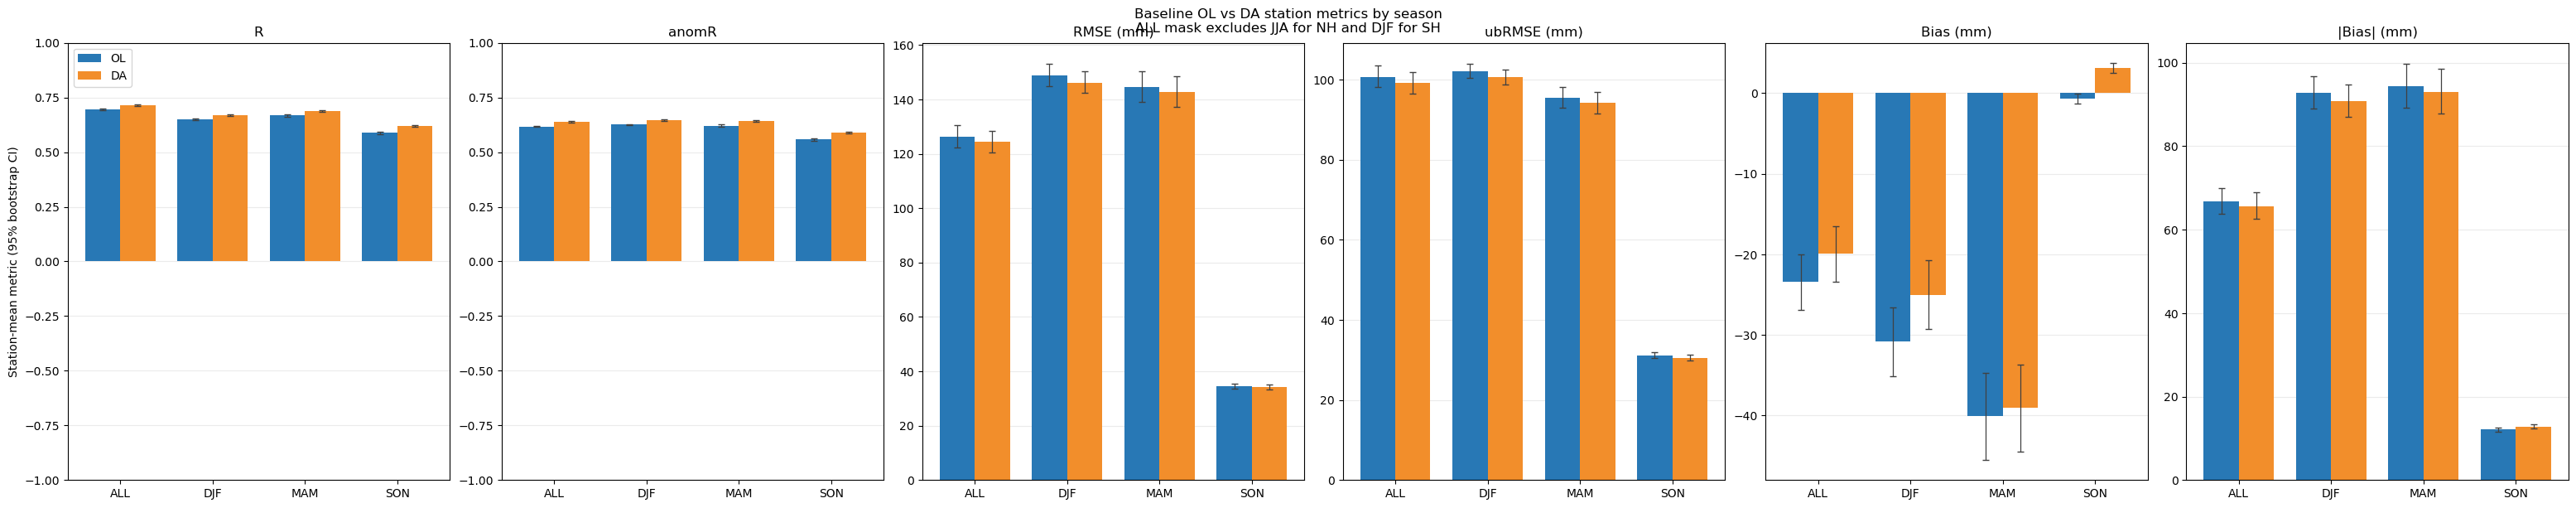

Wrote: /Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/figures/ghcn_baseline_core_ol_vs_da_bars_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.png


In [5]:
# --- Baseline bar plots: OL vs DA for R, anomR, rmse, ubrmse, bias, |bias| ---
metrics = ['R', 'anomR', 'rmse', 'ubrmse', 'bias', 'abs_bias']
metric_label = {
    'R': 'R',
    'anomR': 'anomR',
    'rmse': 'RMSE (mm)',
    'ubrmse': 'ubRMSE (mm)',
    'bias': 'Bias (mm)',
    'abs_bias': '|Bias| (mm)',
}

rows = []
for season_key in SEASONS_PLOT:
    for metric in metrics:
        for exp_key in [EXP_OL, EXP_DA]:
            sub = station_metrics_df[
                (station_metrics_df['season'].astype(str) == season_key)
                & (station_metrics_df['experiment'].astype(str) == exp_key)
            ]
            vals = pd.to_numeric(sub[metric], errors='coerce').to_numpy(dtype=float)
            mu, lo, hi, n = _bootstrap_mean_ci(vals)
            rows.append({
                'season': season_key,
                'metric': metric,
                'experiment': exp_key,
                'mean': mu,
                'ci_low': lo,
                'ci_high': hi,
                'n_station': n,
            })

bar_df = pd.DataFrame(rows)
display(bar_df.head(12))

fig, axes = plt.subplots(1, len(metrics), figsize=(31, 5.8), sharex=True, constrained_layout=True)
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    sub = bar_df[bar_df['metric'] == metric].copy()

    piv = sub.pivot_table(index='season', columns='experiment', values='mean', aggfunc='mean').reindex(SEASONS_PLOT)
    ol_ci = sub[sub['experiment'] == EXP_OL].set_index('season').reindex(SEASONS_PLOT)
    da_ci = sub[sub['experiment'] == EXP_DA].set_index('season').reindex(SEASONS_PLOT)

    y_ol = piv.get(EXP_OL, pd.Series(np.nan, index=SEASONS_PLOT)).to_numpy(dtype=float)
    y_da = piv.get(EXP_DA, pd.Series(np.nan, index=SEASONS_PLOT)).to_numpy(dtype=float)

    yerr_ol = np.vstack([
        np.maximum(0.0, y_ol - ol_ci['ci_low'].to_numpy(dtype=float)),
        np.maximum(0.0, ol_ci['ci_high'].to_numpy(dtype=float) - y_ol),
    ])
    yerr_da = np.vstack([
        np.maximum(0.0, y_da - da_ci['ci_low'].to_numpy(dtype=float)),
        np.maximum(0.0, da_ci['ci_high'].to_numpy(dtype=float) - y_da),
    ])

    x = np.arange(len(SEASONS_PLOT), dtype=float)
    w = 0.38

    ax.bar(x - w / 2, y_ol, width=w, color='#2878B5', label=EXP_OL,
           yerr=np.where(np.isfinite(yerr_ol), yerr_ol, np.nan), capsize=3,
           error_kw={'elinewidth': 0.9, 'ecolor': '0.25'})
    ax.bar(x + w / 2, y_da, width=w, color='#F28E2B', label=EXP_DA,
           yerr=np.where(np.isfinite(yerr_da), yerr_da, np.nan), capsize=3,
           error_kw={'elinewidth': 0.9, 'ecolor': '0.25'})

    ax.set_xticks(x)
    ax.set_xticklabels(SEASONS_PLOT)
    ax.set_title(metric_label[metric])
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)

    if metric in ['R', 'anomR']:
        ax.set_ylim(-1.0, 1.0)

axes[0].set_ylabel('Station-mean metric (95% bootstrap CI)')
axes[0].legend(loc='upper left')

fig.suptitle(
    'Baseline OL vs DA station metrics by season\n'
    + 'ALL mask excludes JJA for NH and DJF for SH',
    y=1.03,
)

bar_fig = FIG_DIR / f'ghcn_baseline_core_ol_vs_da_bars_{cache_tag}.png'
fig.savefig(bar_fig, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {bar_fig}')


NH stations on map: 9,451 (season=ALL)


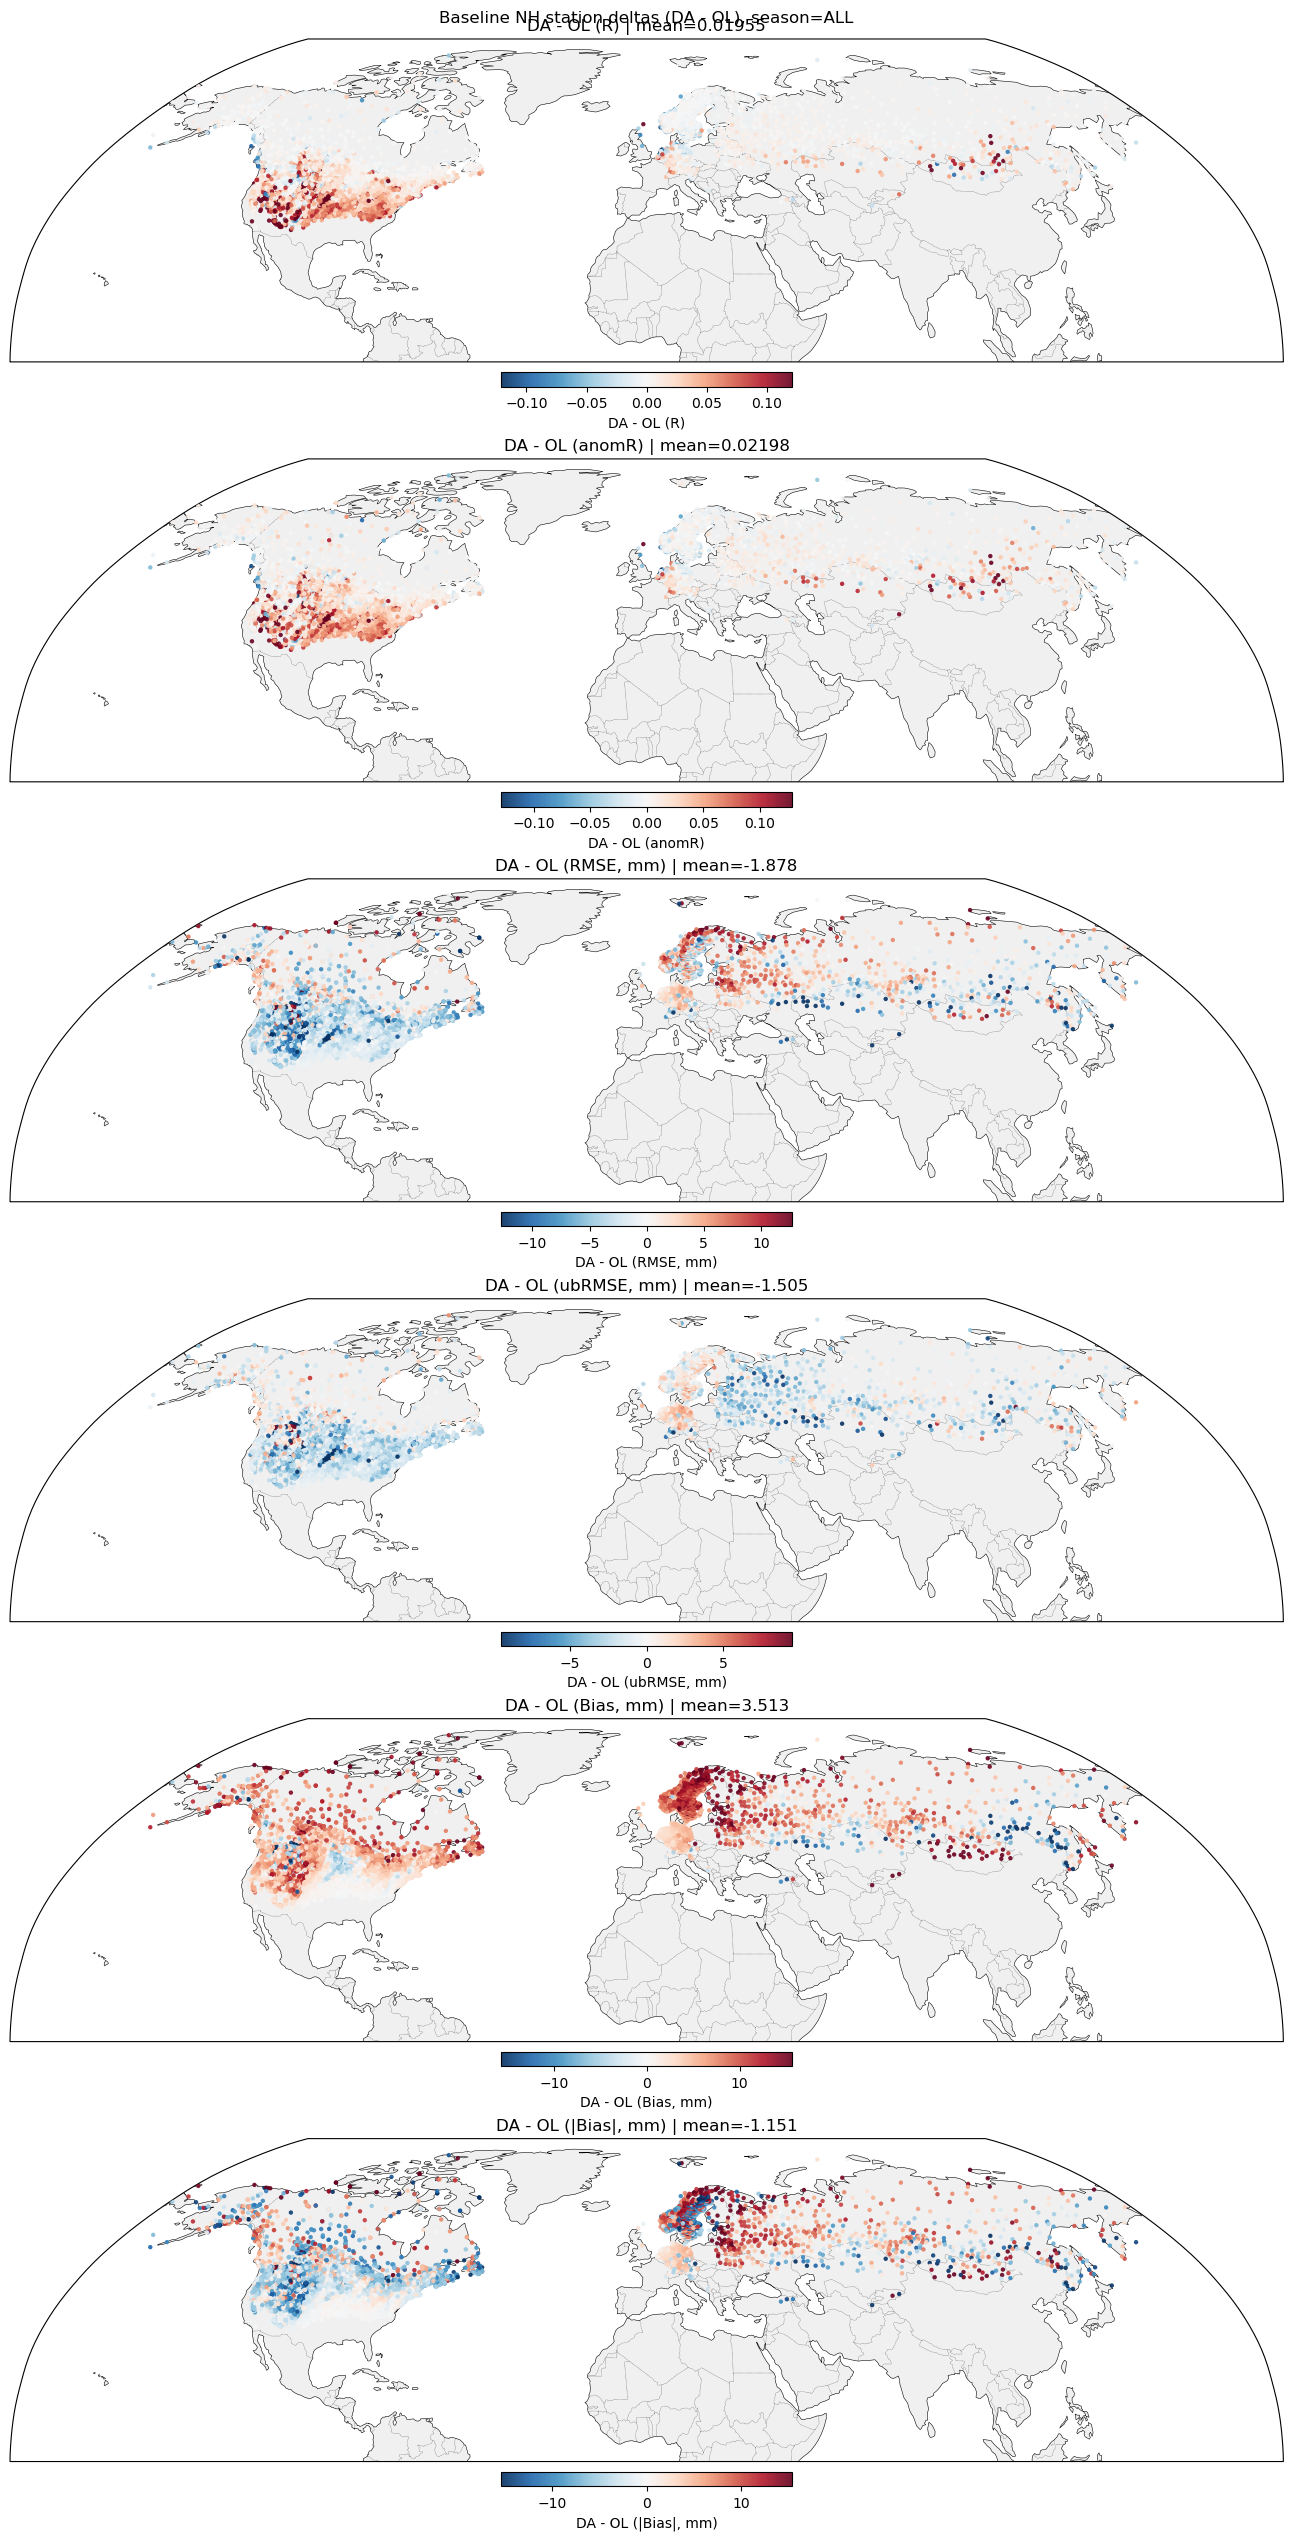

Wrote: /Users/amfox/Desktop/geosldas-analysis/projects/GHCN_snwd/outputs_ghcn_snwd_ol_da_validation/figures/ghcn_baseline_core_nh_delta_maps_da_minus_ol_ALL_SMAP_EASEv2_M36_GLOBAL_20000101_20241231.png


In [6]:
# --- NH Robinson maps: DA - OL deltas for baseline metrics ---
import cartopy.crs as ccrs
import cartopy.feature as cfeature

map_metrics = ['R', 'anomR', 'rmse', 'ubrmse', 'bias', 'abs_bias']
map_titles = {
    'R': 'DA - OL (R)',
    'anomR': 'DA - OL (anomR)',
    'rmse': 'DA - OL (RMSE, mm)',
    'ubrmse': 'DA - OL (ubRMSE, mm)',
    'bias': 'DA - OL (Bias, mm)',
    'abs_bias': 'DA - OL (|Bias|, mm)',
}

sub = station_metrics_df[
    (station_metrics_df['season'].astype(str) == MAP_SEASON)
    & (station_metrics_df['variable'].astype(str) == 'SNODPLAND')
].copy()

need = {'station', 'experiment', 'station_lat', 'station_lon', *map_metrics}
missing = need - set(sub.columns)
if missing:
    raise KeyError(f'station_metrics_df missing required map columns: {sorted(missing)}')

for c in ['station_lat', 'station_lon', *map_metrics]:
    sub[c] = pd.to_numeric(sub[c], errors='coerce')

latlon = sub.groupby('station', as_index=False).agg(
    station_lat=('station_lat', 'first'),
    station_lon=('station_lon', 'first'),
)

delta_df = latlon.copy()
for metric in map_metrics:
    piv = sub.pivot_table(index='station', columns='experiment', values=metric, aggfunc='mean').reset_index()
    if EXP_OL not in piv.columns:
        piv[EXP_OL] = np.nan
    if EXP_DA not in piv.columns:
        piv[EXP_DA] = np.nan
    piv[f'delta_{metric}'] = pd.to_numeric(piv[EXP_DA], errors='coerce') - pd.to_numeric(piv[EXP_OL], errors='coerce')
    delta_df = delta_df.merge(piv[['station', f'delta_{metric}']], on='station', how='left')

delta_df = delta_df[
    np.isfinite(pd.to_numeric(delta_df['station_lat'], errors='coerce'))
    & np.isfinite(pd.to_numeric(delta_df['station_lon'], errors='coerce'))
    & (pd.to_numeric(delta_df['station_lat'], errors='coerce') >= 0.0)
].copy()

print(f'NH stations on map: {len(delta_df):,} (season={MAP_SEASON})')

proj = ccrs.Robinson()
nrows = len(map_metrics)
fig, axes = plt.subplots(nrows, 1, figsize=(14.5, 4.2 * nrows), subplot_kw={'projection': proj}, constrained_layout=True)

for ax, metric in zip(axes, map_metrics):
    col = f'delta_{metric}'
    vals = pd.to_numeric(delta_df[col], errors='coerce').to_numpy(dtype=float)

    ok = np.isfinite(vals)
    if np.any(ok):
        vlim = float(np.nanpercentile(np.abs(vals[ok]), 98))
        if (not np.isfinite(vlim)) or (vlim <= 0):
            vlim = float(np.nanmax(np.abs(vals[ok]))) if np.any(np.isfinite(vals[ok])) else 1.0
        if (not np.isfinite(vlim)) or (vlim <= 0):
            vlim = 1.0

        norm = TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

        sc = ax.scatter(
            delta_df.loc[ok, 'station_lon'].to_numpy(dtype=float),
            delta_df.loc[ok, 'station_lat'].to_numpy(dtype=float),
            c=vals[ok],
            s=10,
            cmap='RdBu_r',
            norm=norm,
            transform=ccrs.PlateCarree(),
            linewidths=0,
            alpha=0.9,
            zorder=3,
        )

        mean_val = float(np.nanmean(vals[ok]))
    else:
        sc = None
        mean_val = np.nan

    ax.add_feature(cfeature.LAND, facecolor='0.94', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)
    ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

    ttl = map_titles[metric]
    if np.isfinite(mean_val):
        ttl += f' | mean={mean_val:.4g}'
    ax.set_title(ttl)

    if sc is not None:
        cb = fig.colorbar(sc, ax=ax, orientation='horizontal', fraction=0.045, pad=0.03)
        cb.set_label(map_titles[metric])

fig.suptitle(f'Baseline NH station deltas (DA - OL), season={MAP_SEASON}', y=1.002)
map_fig = FIG_DIR / f'ghcn_baseline_core_nh_delta_maps_da_minus_ol_{MAP_SEASON}_{cache_tag}.png'
fig.savefig(map_fig, dpi=220, bbox_inches='tight')
plt.show()
print(f'Wrote: {map_fig}')
